In [21]:
import pandas as pd
import numpy as np
import multiprocessing as mp
import matplotlib.pyplot as plt
import json
import seaborn as sns
from catomatic.BinaryCatalogue import BinaryBuilder
import matplotlib
from collections import defaultdict
from matplotlib.collections import PolyCollection
from itertools import product
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

from matplotlib.collections import PolyCollection

from protocols import utils, functions, graphs

plt.rcParams['figure.dpi'] = 200
plt.rcParams['font.family'] = 'Helvetica'  
plt.rcParams['font.size'] = 7 
plt.rcParams['figure.figsize'] = (6.69, 5.02)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Determine the effect of FRS when building the catalogue and when using it to make predictions

There are 2 minimum read support thresholds that need to be set: one for building the catalogue, and one for using the catalogue to make predictions.

We need to determine the effect of both.

## Import optimised catalogue parameters

This catalogue was generated in 02-grid-search.ipynb

In [ ]:
# the path to the CRyPTIC v3.1.0 data tables (including the DST_MEASUREMENTS_+.pkl which has DST for the validation samples appended)
cryptic_tables_path = 'data/cryptic-tables-v3.4.0/'

#read in genes relevant to each drug
with open('data/drug_to_genes.json', 'r') as f:
    drug_genes = json.load(f)

# whether to run the processes which take a long time
run_long_processes = False

# number of cores
n_cores = 9

In [23]:
#read in optimal catalogues determined in 02-gred-search.ipynb
opt_cats = pd.read_csv('results/grid_search/opt_cats_MTBC-CRyPTICv1.1.1-2025.8.csv')
opt_cats

,DRUG,BACKGROUND_RATE,conf_level,SENSITIVITY,SPECIFICITY,DPR,SENSITIVITY2,SPECIFICITY2,Score,R,S,U,Total,catalogue
0,RIF,0.20,0.90,0.961417,0.985268,0.971120,0.943997,0.985760,0.970513,42,16,352,410,MTBC-CRyPTICv1.1.1-2025.8
1,INH,0.25,0.90,0.945534,0.987895,0.956970,0.917435,0.988510,0.960530,62,23,626,711,MTBC-CRyPTICv1.1.1-2025.8
2,STM,0.15,0.90,0.954290,0.931818,0.914743,0.896104,0.938396,0.939639,115,8,542,665,MTBC-CRyPTICv1.1.1-2025.8
3,LEV,0.25,0.90,0.923222,0.971103,0.932654,0.894161,0.973286,0.939473,13,19,330,362,MTBC-CRyPTICv1.1.1-2025.8
4,MXF,0.25,0.95,0.940669,0.941006,0.931879,0.914180,0.945520,0.939012,11,22,489,522,MTBC-CRyPTICv1.1.1-2025.8
5,EMB,0.25,0.90,0.947307,0.919858,0.908448,0.875294,0.927433,0.931300,20,58,1056,1134,MTBC-CRyPTICv1.1.1-2025.8
6,PZA,0.05,0.90,0.863924,0.972718,0.976187,0.855799,0.973436,0.919015,440,0,143,583,MTBC-CRyPTICv1.1.1-2025.8
7,AMI,0.05,0.90,0.874486,0.982756,0.921091,0.851703,0.984194,0.916288,11,6,383,400,MTBC-CRyPTICv1.1.1-2025.8
8,CAP,0.05,0.90,0.840217,0.976051,0.922950,0.808577,0.977981,0.897514,43,2,234,279,MTBC-CRyPTICv1.1.1-2025.8
9,ETH,0.05,0.90,0.908987,0.869838,0.896154,0.823346,0.883667,0.894676,298,0,325,623,MTBC-CRyPTICv1.1.1-2025.8


## Calculate performance when built and tested at each FRS

The parellised pipeline below follow the same workflow used in 01-example.ipynb, but min FRS' are varied.

In [24]:
#define minimum FRS values
build_frs_values = np.arange(0.1, 1.0, 0.1)
#build_frs_values = [0.1, 0.9]
test_frs_values = np.arange(0.1, 1.0, 0.1)
#test_frs_values = [0.1]


# Shared memory dictionaries for storing results
manager = mp.Manager()
sensitivity_matrix = manager.dict()
specificity_matrix = manager.dict()
dpr_matrix = manager.dict()
sensitivity2_matrix = manager.dict()
specificity2_matrix = manager.dict()
tp_matrix= manager.dict()
fn_matrix = manager.dict()
tn_matrix = manager.dict()
fp_matrix = manager.dict()
up_matrix = manager.dict()
un_matrix = manager.dict()

def process_drug_frs(args):
    '''build and test catalogues at each specified minimum FRS'''

    drug, build_FRS = args
    #prep mutations data
    mutations = functions.prep_mutations('data/mutations-v3.4.0/', 
                                    drug_genes[drug]['genes'], 
                                    version='v3.4.0', 
                                    mut_path=cryptic_tables_path+'MUTATIONS.parquet', 
                                    var_path=cryptic_tables_path+'VARIANTS.parquet', 
                                    train=True)
    
    test_mutations = functions.prep_mutations('data/mutations-v3.4.0/', 
                                    drug_genes[drug]['genes'], 
                                    version='v3.4.0', 
                                    mut_path=cryptic_tables_path+'MUTATIONS.parquet', 
                                    var_path=cryptic_tables_path+'VARIANTS.parquet', 
                                    train=False)
    #prep phenotypes data
    phenotypes = functions.prep_phenotypes(
        drug,
        cryptic_tables_path+"DST_MEASUREMENTS.parquet",
        #cryptic_tables_path+"GENOMES.parquet",
        cryptic_tables_path+"WGS_SAMPLES.parquet",
        'v3.4.0',
        validation=False
    )
    
    background, p = opt_cats.loc[opt_cats.DRUG == drug, ['BACKGROUND_RATE', 'conf_level']].iloc[0]
    sens_results, spec_results, cov_results, sens2_results, spec2_results = {}, {}, {}, {}, {}
    tp_results, fn_results, tn_results, fp_results, up_results, un_results = {}, {}, {}, {}, {}, {}

    
    # Build a catalogue for specified drug at specified FRS   
    catfile = f"./catalogues/MTBC-CRyPTICv1.1.1-2025.8/frs/{drug.lower()}/bg_{background}_p_{p}_FRS_{np.round(build_FRS,1)}.csv"
    #catalogue = BinaryBuilder(samples=phenotypes, mutations=mutations, frs=build_FRS, seed=drug_genes[drug]['phylogenetic']).build(
     #   test='Binomial', background=background, strict_unlock=True, p=p
    #)
    print(f'{drug}-{background}-{p}-{np.round(build_FRS, 1)}')
    #catalogue.to_piezo(
    #    genbank_ref='NC00962.3',
    #    catalogue_name=f'{drug}-{background}-{p}-{np.round(build_FRS, 1)}',
    #    version='0.0',
    #    drug=drug,
    #    wildcards=f"./data/wildcards/{drug.lower()}_wildcards.json",
    #    json_dumps=True,
    #    outfile=catfile
    #)

    sens_results[build_FRS], spec_results[build_FRS], cov_results[build_FRS] = {}, {}, {}
    sens2_results[build_FRS], spec2_results[build_FRS] = {}, {} 
    tp_results[build_FRS], fn_results[build_FRS], tn_results[build_FRS] = {}, {}, {}
    fp_results[build_FRS], up_results[build_FRS], un_results[build_FRS] = {}, {}, {}
    
    #determine catalogue performance at the specified test FRS
    for test_FRS in test_frs_values:
        all_data = pd.merge(
            phenotypes,
            test_mutations[test_mutations.FRS >= test_FRS],
            on=['UNIQUEID'],
            how='left'
        )
        print (drug, build_FRS, test_FRS)
        cm, cov, sens, spec, ppv, sens2, spec2 = functions.piezo_predict(iso_df=all_data, drug=drug, catalogue_file=catfile)

        TP = cm[0, 0]
        FN = cm[0, 1]
        TN = cm[1, 1]
        FP = cm[1, 0]
        UP = cm[0, 2]
        UN = cm[1, 2]


        sens_results[build_FRS][test_FRS] = sens * 100
        spec_results[build_FRS][test_FRS] = spec * 100
        cov_results[build_FRS][test_FRS] = cov * 100
        sens2_results[build_FRS][test_FRS] = sens2 * 100
        spec2_results[build_FRS][test_FRS] = spec2 * 100

        tp_results[build_FRS][test_FRS] = TP
        fn_results[build_FRS][test_FRS] = FN
        tn_results[build_FRS][test_FRS] = TN
        fp_results[build_FRS][test_FRS] = FP
        up_results[build_FRS][test_FRS] = UP
        un_results[build_FRS][test_FRS] = UN

    sensitivity_matrix[(drug, build_FRS)] = sens_results[build_FRS]
    specificity_matrix[(drug, build_FRS)] = spec_results[build_FRS]
    dpr_matrix[(drug, build_FRS)] = cov_results[build_FRS]
    sensitivity2_matrix[(drug, build_FRS)] = sens2_results[build_FRS]
    specificity2_matrix[(drug, build_FRS)] = spec2_results[build_FRS]

    tp_matrix[(drug, build_FRS)] = tp_results[build_FRS]
    fn_matrix[(drug, build_FRS)] = fn_results[build_FRS]
    tn_matrix[(drug, build_FRS)] = tn_results[build_FRS]
    fp_matrix[(drug, build_FRS)] = fp_results[build_FRS]
    up_matrix[(drug, build_FRS)] = up_results[build_FRS]
    un_matrix[(drug, build_FRS)] = un_results[build_FRS]


def convert_to_dataframe(matrix, metric):
    data = []
    for (drug, build_FRS), test_results in matrix.items():
        for test_FRS, value in test_results.items():
            data.append([drug, build_FRS, test_FRS, value])
    df = pd.DataFrame(data, columns=['Drug', 'Build_FRS', 'Test_FRS', metric])
    df.set_index(['Drug', 'Build_FRS', 'Test_FRS'], inplace=True)
    return df


# Parallelise and run FRS Scan

For clarity have just run for amikacin here - remove drug filter for opt_cats to run for all drugs (will take a few hours).

In [25]:
#remve to run for all drugs
#opt_cats = opt_cats[opt_cats.DRUG=='MXF']

# Parallel execution
if run_long_processes:
    mp.set_start_method('fork', force=True)
    all_tasks = list(product(opt_cats.DRUG.values, build_frs_values))
    with mp.Pool(n_cores) as pool:
        pool.map(process_drug_frs, all_tasks)

    matrices = {
        'Sensitivity': sensitivity_matrix,
        'Specificity': specificity_matrix,
        'DPR': dpr_matrix,
        'Sensitivity2': sensitivity2_matrix,
        'Specificity2': specificity2_matrix,
        'TP': tp_matrix,
        'FN': fn_matrix,
        'TN': tn_matrix,
        'FP': fp_matrix,
        'UP': up_matrix,
        'UN': un_matrix,
    }

    perf_df = pd.concat(
        [convert_to_dataframe(m, name) for name, m in matrices.items()],
        axis=1
    )
    perf_df.to_csv(
        'results/frs/MTBC-CRyPTICv1.1.1-2025.8_train_perf.csv', index=True
    )
else:
    perf_df = pd.read_csv(
        'results/frs/MTBC-CRyPTICv1.1.1-2025.8_train_perf.csv'
    )


#format results 
perf_df.reset_index(inplace=True)
catalogued_R, catalogued_S, catalogued_RS = [], [], []
for i in perf_df.index:
    drug = perf_df['Drug'][i]
    background = opt_cats[opt_cats.DRUG==drug].BACKGROUND_RATE.values[0]
    p = opt_cats[opt_cats.DRUG==drug].conf_level.values[0]
    build_FRS = perf_df['Build_FRS'][i]
    catfile = f"./catalogues/MTBC-CRyPTICv1.1.1-2025.8/frs/{drug.lower()}/bg_{background}_p_{p}_FRS_{np.round(build_FRS,1)}.csv"
    cat = pd.read_csv(catfile)
    catalogued_R.append(cat[(cat.PREDICTION == 'R') & (~cat.MUTATION.str.contains(r'\*'))].MUTATION.nunique())
    catalogued_S.append(cat[(cat.PREDICTION == 'S') & (~cat.MUTATION.str.contains(r'\*'))].MUTATION.nunique())
    catalogued_RS.append(cat[(cat.PREDICTION.isin(['R', 'S'])) & (~cat.MUTATION.str.contains(r'\*'))].MUTATION.nunique())
perf_df['catalogued_R'] = catalogued_R
perf_df['catalogued_S'] = catalogued_S
perf_df['catalogued_RS'] = catalogued_RS

perf_df


STM-0.15-0.9-0.7
STM-0.15-0.9-0.3
STM 0.7000000000000001 0.1
STM 0.30000000000000004 0.1
LEV-0.25-0.9-0.6
LEV 0.6000000000000001 0.1
LEV-0.25-0.9-0.2
LEV 0.2 0.1
INH-0.25-0.9-0.4
INHRIF-0.2-0.9-0.1
 0.4RIF  0.10.1
 0.1
RIF-0.2-0.9-0.9
RIF-0.2-0.9-0.5
RIF 0.9 INH-0.25-0.9-0.80.1

RIF 0.5 0.1
INH 0.8 0.1
STM 0.7000000000000001 0.2
STM 0.30000000000000004 0.2
LEV 0.2 0.2
LEV 0.6000000000000001 0.2
STM 0.30000000000000004 0.30000000000000004
STM 0.7000000000000001 0.30000000000000004
STM 0.30000000000000004 0.4
STM 0.7000000000000001 0.4
LEV 0.2 0.30000000000000004
LEV 0.6000000000000001 0.30000000000000004
RIF 0.5 0.2
RIF 0.9 0.2
RIF 0.1 0.2
STM 0.30000000000000004 0.5
INH 0.4 0.2
INH 0.8 0.2
STM 0.7000000000000001 0.5
STM 0.30000000000000004 0.6000000000000001
LEV 0.2 0.4
LEV 0.6000000000000001 0.4
STM 0.7000000000000001 0.6000000000000001
STM 0.30000000000000004 0.7000000000000001
STM 0.7000000000000001 0.7000000000000001
LEV 0.2 0.5
LEV 0.6000000000000001 0.5
STM 0.30000000000000004 0.

,Drug,Build_FRS,Test_FRS,Sensitivity,Specificity,DPR,Sensitivity2,Specificity2,TP,FN,TN,FP,UP,UN,catalogued_R,catalogued_S,catalogued_RS
0,STM,0.3,0.1,95.443925,93.024823,91.675939,89.918556,93.687100,4085,195,8282,621,263,934,117,8,125
1,STM,0.3,0.2,95.259225,93.078304,91.766342,89.786485,93.727763,4079,203,8297,617,261,923,117,8,125
2,STM,0.3,0.3,95.162421,93.127032,91.780250,89.632401,93.768425,4072,207,8306,613,264,918,117,8,125
3,STM,0.3,0.4,94.952092,93.183857,91.787204,89.434295,93.819254,4063,216,8312,608,264,917,117,8,125
4,STM,0.3,0.5,94.763908,93.219769,91.801113,89.236188,93.849751,4054,224,8318,605,265,914,117,8,125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1210,CFZ,0.6,0.5,15.789474,99.207019,96.445386,15.299335,99.235337,69,368,11760,94,14,439,47,0,47
1211,CFZ,0.6,0.6,14.772727,99.241147,96.516008,14.412417,99.267876,65,375,11770,90,11,433,47,0,47
1212,CFZ,0.6,0.7,13.409091,99.266813,96.563089,13.082040,99.292280,59,381,11779,87,11,427,47,0,47
1213,CFZ,0.6,0.8,12.954545,99.292751,96.649404,12.638581,99.316684,57,383,11793,84,11,416,47,0,47


## Example of results for MXF

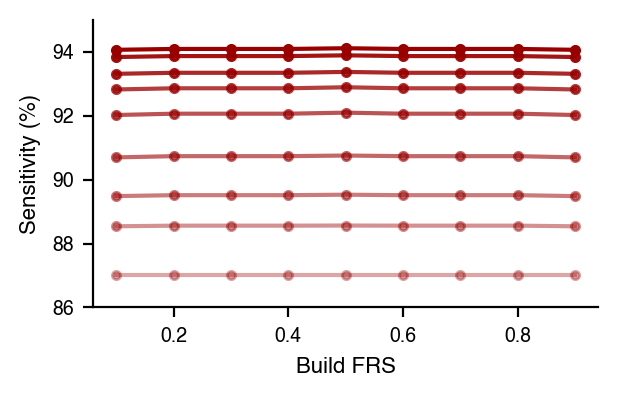

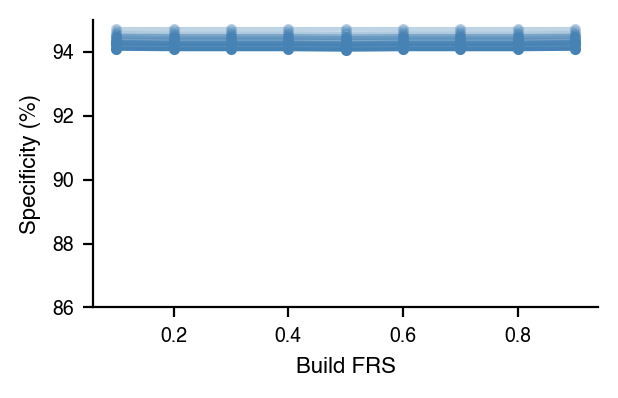

In [40]:
#filter for drug
drug_df = perf_df[perf_df["Drug"] == 'MXF'].copy()

# Round Build_FRS to 2 decimals to avoid float noise
drug_df["Build_FRS"] = drug_df["Build_FRS"].round(2)

graphs.plot_frs_sens(drug_df.sort_values('Build_FRS'))

graphs.plot_frs_spec(drug_df.sort_values('Build_FRS'))

## Plot bar charts of number of R or S classifications for each drug

Just show amikacin as an example

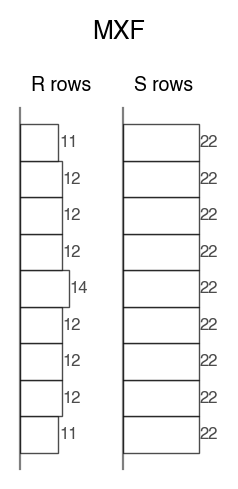

In [41]:
#remove drug filter for all heatmaps
graphs.plot_catalogue_bar_charts(perf_df[perf_df.Drug=='MXF'])

## Plot heatmaps of sensitivity, specificity, and DPR for the FRS the catalogues are built at vs tested at

Similar to line plot above, just more compact to display each metric.

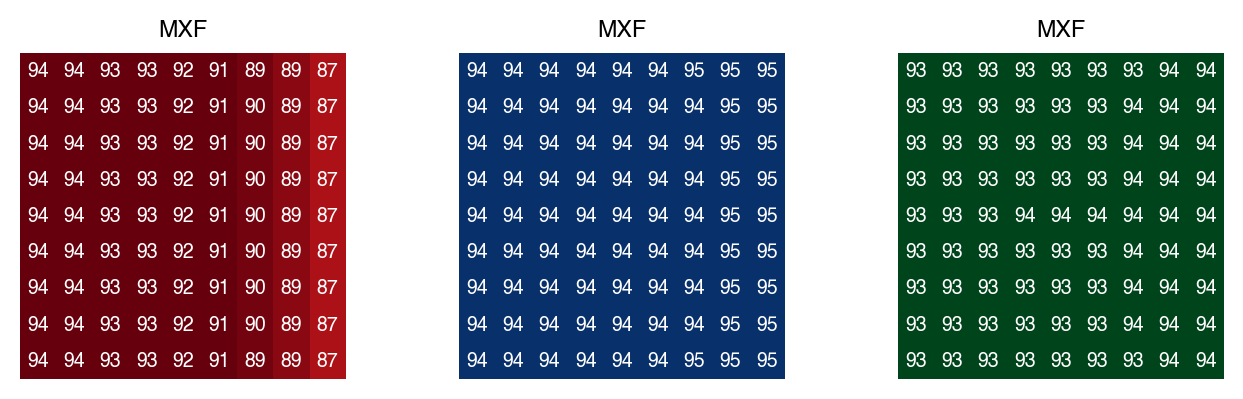

In [28]:


perf_df = perf_df.drop_duplicates(['Drug', 'Build_FRS', 'Test_FRS'], keep='first')
#remove drug filter for all heatmaps
graphs.plot_perf_heatmaps(perf_df[perf_df.Drug=='MXF'], draw_axes=False)
#x axis = test minimum FRS, y axis = build minimum FRS

## Pvals for build FRS = 0.1, and 0.1 == test FRS | 0.9 == test frs

Is there a signifficant difference between highest and lowest minimum FRS when making perdictions?

In [29]:
def generate_pvals(df, comparisons):
    '''caluclate pvalues (proportions Z-test) for specifieid comparitors.
    e.g [('catomatic_v3.4.0', 'WHOv1'), ('catomatic_v3.4.0', 'WHOv2'), ('WHOv1', 'WHOv2')]'''

    assert comparisons is not None, 'comparison keys must be spcified'

    metric_funcs = {
        'sens_conf_level': lambda r: (r['TP'], r['TP'] + r['FN']),
        'spec_conf_level': lambda r: (r['TN'], r['TN'] + r['FP']),
        'dpr_conf_level': lambda r: (r['TP'] + r['TN'] + r['FP'] + r['FN'], 
                                r['TP'] + r['TN'] + r['FP'] + r['FN'] + r['UP'] + r['UN']),
    }
    results = []
    # Loop over each drug and comparison
    for drug in df['Drug'].unique():
        df_drug = df[df['Drug'] == drug]
        for cat1, cat2 in comparisons:
            row = {'Drug': drug, 'Comparison': f'{cat1} > {cat2}'}
            g1 = df_drug[df_drug['Test_FRS'] == cat1].iloc[0]
            g2 = df_drug[df_drug['Test_FRS'] == cat2].iloc[0]
            for col_name, fn in metric_funcs.items():
                c1, n1 = fn(g1)
                c2, n2 = fn(g2)
                stat, pval = proportions_ztest([c1, c2], [n1, n2], alternative='two-sided')
                row[col_name] = pval
            results.append(row)

    return pd.DataFrame(results)

def compute_metric_differences(results_df, pvals_df):
    """
    Compute differences in performance metrics between comparator catalogues
    specified in pvals_df for each drug.
    """
    metrics = ['Sensitivity', 'Specificity', 'DPR']
    diffs = []

    for _, row in pvals_df.iterrows():
        drug = row['Drug']
        cat1, cat2 = row['Comparison'].split(' > ')

        r1 = results_df[(results_df['Drug'] == drug) & (results_df['Test_FRS'] == cat1)].iloc[0]
        r2 = results_df[(results_df['Drug'] == drug) & (results_df['Test_FRS'] == cat2)].iloc[0]

        diff_row = {'Drug': drug, 'Comparison': row['Comparison']}
        for metric in metrics:
            diff_row[f'{metric}_diff'] = r1[metric] - r2[metric]

        diffs.append(diff_row)

    return pd.DataFrame(diffs)

perf_df_p = perf_df[
    ((perf_df.Build_FRS == 0.1)) &
    ((perf_df.Test_FRS == 0.1) | (perf_df.Test_FRS == 0.9))
]
perf_df_p['Build_FRS'] = perf_df_p.Build_FRS.astype(str)
perf_df_p['Test_FRS'] = perf_df_p.Test_FRS.astype(str)
pvals = generate_pvals(perf_df_p, comparisons=[('0.1', '0.9')])
pvals


/var/folders/s5/pshvb2093574r5hqnwcy6klw0000gn/T/ipykernel_39166/1223689189.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  perf_df_p['Build_FRS'] = perf_df_p.Build_FRS.astype(str)
/var/folders/s5/pshvb2093574r5hqnwcy6klw0000gn/T/ipykernel_39166/1223689189.py:58: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  perf_df_p['Test_FRS'] = perf_df_p.Test_FRS.astype(str)


,Drug,Comparison,sens_conf_level,spec_conf_level,dpr_conf_level
0,RIF,0.1 > 0.9,6.665922e-13,0.211719,0.073555
1,LEV,0.1 > 0.9,5.705191e-17,0.134762,0.095078
2,MXF,0.1 > 0.9,3.850715e-20,0.027163,0.038172
3,INH,0.1 > 0.9,9.236247e-09,0.167033,0.034388
4,STM,0.1 > 0.9,1.658250e-06,0.478861,0.286574
5,EMB,0.1 > 0.9,1.315862e-08,0.032336,0.000002
6,CAP,0.1 > 0.9,3.056233e-05,0.034743,0.220496
7,PZA,0.1 > 0.9,4.560653e-09,0.031713,0.065116
8,AMI,0.1 > 0.9,1.040509e-05,0.108907,0.091448
9,ETH,0.1 > 0.9,7.586060e-06,0.068522,0.020699


In [30]:
compute_metric_differences(perf_df_p, pvals)

,Drug,Comparison,Sensitivity_diff,Specificity_diff,DPR_diff
0,RIF,0.1 > 0.9,2.121540,-0.131014,-0.216327
1,LEV,0.1 > 0.9,8.286605,-0.364181,-0.535032
2,MXF,0.1 > 0.9,7.059720,-0.625464,-0.552647
3,INH,0.1 > 0.9,1.714015,-0.138823,-0.309473
4,STM,0.1 > 0.9,2.419855,-0.265028,-0.347705
5,EMB,0.1 > 0.9,2.806526,-0.498377,-1.020142
6,CAP,0.1 > 0.9,7.748716,-0.440938,-0.424684
7,PZA,0.1 > 0.9,5.450559,-0.356311,-0.262540
8,AMI,0.1 > 0.9,5.911154,-0.223768,-0.458047
9,ETH,0.1 > 0.9,3.872865,-0.837642,-0.814748


## Confidence limit waterfall plots - analyse why performance changes by tracking mutations

### for mutations which are not consistently classified as R/S across different FRS thresholds for each drug.


In [31]:
#determine which mutaitons change classiication as the FRS is varied
varying_mutations = {}
for drug in perf_df.Drug.unique():
    muts = {}
    df = perf_df[perf_df.Drug == drug].reset_index()
    
    for i in df.drop_duplicates(['Build_FRS'], keep='first').index:
        background = opt_cats[opt_cats.DRUG == drug].BACKGROUND_RATE.values[0]
        p = opt_cats[opt_cats.DRUG == drug].conf_level.values[0]
        build_FRS = df['Build_FRS'][i]
        catfile = f"./catalogues/MTBC-CRyPTICv1.1.1-2025.8/frs/{drug.lower()}/bg_{background}_p_{p}_FRS_{np.round(build_FRS,1)}.csv"
        cat = pd.read_csv(catfile)
        cat = cat[(cat.PREDICTION.isin(['R', 'S'])) & (~cat.MUTATION.str.contains(r'\*'))]
        muts[float(build_FRS)] = set(cat.MUTATION.values)  # Make them sets!

    all_muts_sets = list(muts.values())
    
    common_muts = set.intersection(*all_muts_sets)
    
    varying_muts = set.union(*all_muts_sets) - common_muts
    
    print(f"Drug: {drug}")
    print(f"Varying Mutations (changing across FRS):")
    print(varying_muts)
    print("-" * 40)
    varying_mutations[drug] = varying_muts


Drug: STM
Varying Mutations (changing across FRS):
{'gid@A200E', 'rrs@a906g', 'gid@R96C', 'rrs@c1443g', 'gid@52_del_c', 'gid@V65A', 'gid@26_del_ctgcgatcttcggaccgcggcttggccttgctcggcggtacgccgaagcgt'}
----------------------------------------
Drug: LEV
Varying Mutations (changing across FRS):
{'gyrA@L105R', 'gyrB@N499K', 'gyrB@E501D', 'gyrA@D94C', 'gyrA@D94S', 'gyrA@D94R'}
----------------------------------------
Drug: RIF
Varying Mutations (changing across FRS):
{'rpoB@H445F', 'rpoB@M390T', 'rpoB@L449Q', 'rpoB@H445N', 'rpoB@D545E', 'rpoB@H445V', 'rpoB@E761D', 'rpoB@H445P', 'rpoB@L430P', 'rpoB@1301_del_tgg', 'rpoB@1297_del_ttcatggac'}
----------------------------------------
Drug: INH
Varying Mutations (changing across FRS):
{'ahpC@V50G', 'fabG1@T213P', 'ahpC@W53L', 'katG@Q439R', 'katG@2005_ins_g', 'katG@A172T', 'katG@P232R', 'katG@W300G', 'katG@G299S', 'katG@Q461P', 'katG@V473F', 'katG@L298S', 'katG@H97L', 'katG@A727S', 'katG@N637K', 'ahpC@V49G', 'fabG1@c-60g', 'katG@D142G', 'ahpC@c-54t',

In [32]:
#extract proportion solo R from the catalogue and confidence limits

frs_prop_data = defaultdict(lambda: defaultdict(lambda: {'count': [], 'frs': [], 'y': [], 'error': []}))

to_float = lambda x: float(x) if isinstance(x, np.float64) else x

for drug, mutations in varying_mutations.items():  # <<-- use your new varying mutation dictionary
    background, p = opt_cats.loc[opt_cats.DRUG == drug, ['BACKGROUND_RATE', 'conf_level']].iloc[0]
    print (drug)
    for frs in build_frs_values:
        # Load the catalogue
        catalogue = utils.load_catomatic_catalogue(
            drug, background, p, np.round(frs, 1), dir='catalogues/MTBC-CRyPTICv1.1.1-2025.8/frs/'
        )

        catalogue = catalogue[catalogue.EVIDENCE!={'seeded': 'True'}	]
        
        for field in ['PROPORTION', 'CONFIDENCE', 'SOLO_CONTINGENCY']:
            catalogue[field] = catalogue['EVIDENCE'].apply(lambda x: utils.extract_value(x, field.lower()))

        catalogue['MUT_COUNT'] = catalogue['SOLO_CONTINGENCY'].apply(lambda c: c[0][0] + c[0][1])
        # Filter only to relevant mutations (varying ones for this drug)
        catalogue_muts = catalogue[catalogue.MUTATION.isin(mutations)]

        def extract_errors(df, prop_col, conf_col):
            def clean_ci(ci):
                if isinstance(ci, list) and len(ci) == 2:
                    return [max(0, np.round(float(ci[0]), 3)), min(1, np.round(float(ci[1]), 3))] 
                return [np.nan, np.nan]

            prop = df[prop_col]
            err = df[conf_col].apply(clean_ci)

            if len(prop) > 1:
                return (np.array(prop).flatten(), np.vstack(err))
            elif len(prop) == 1:
                return (np.array(prop).flatten(), np.stack(err.values).T)
            else:
                return (np.array(prop).flatten(), err.to_numpy())
        #pull out confidence limits and proportions of ressitance for each mutation from the catalogue
        prop, error = extract_errors(catalogue_muts, 'PROPORTION', 'CONFIDENCE')

        # Save required data for plotting
        for i, mutation in enumerate(catalogue_muts.MUTATION.tolist()):
            mut_count = catalogue_muts.iloc[i]['MUT_COUNT']  
            frs_prop_data[drug][mutation]['frs'].append(to_float(frs))
            frs_prop_data[drug][mutation]['y'].append(prop[i])
            frs_prop_data[drug][mutation]['count'].append(mut_count) 

            frs_prop_data[drug][mutation]['error'].append(error[i] if prop.shape[0] > 1 else error)
            frs_prop_data[drug][mutation]['background'] = background

# Make final dict cleaner
frs_prop_data = {drug: dict(mutations) for drug, mutations in frs_prop_data.items()}


STM
LEV
RIF
INH
MXF
EMB
PZA
AMI
CAP
ETH
BDQ
KAN
LZD
DLM
CFZ


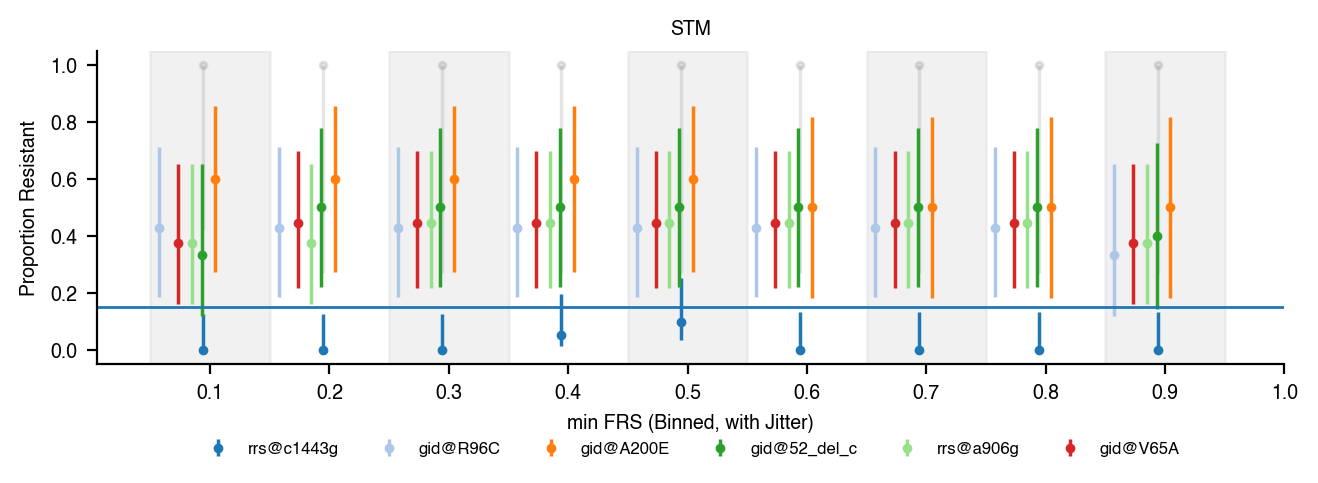

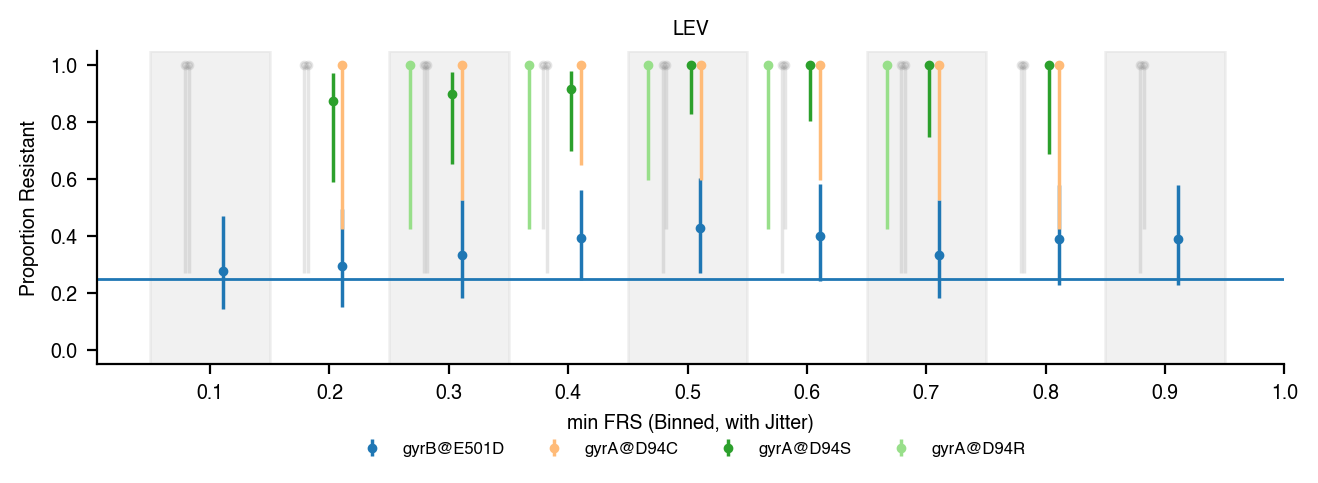

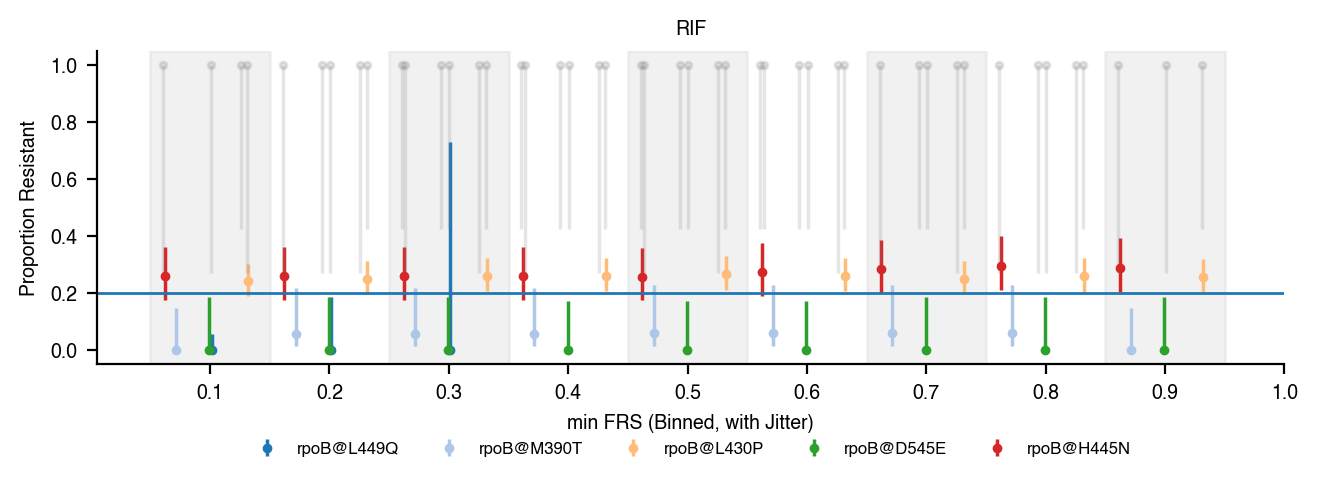

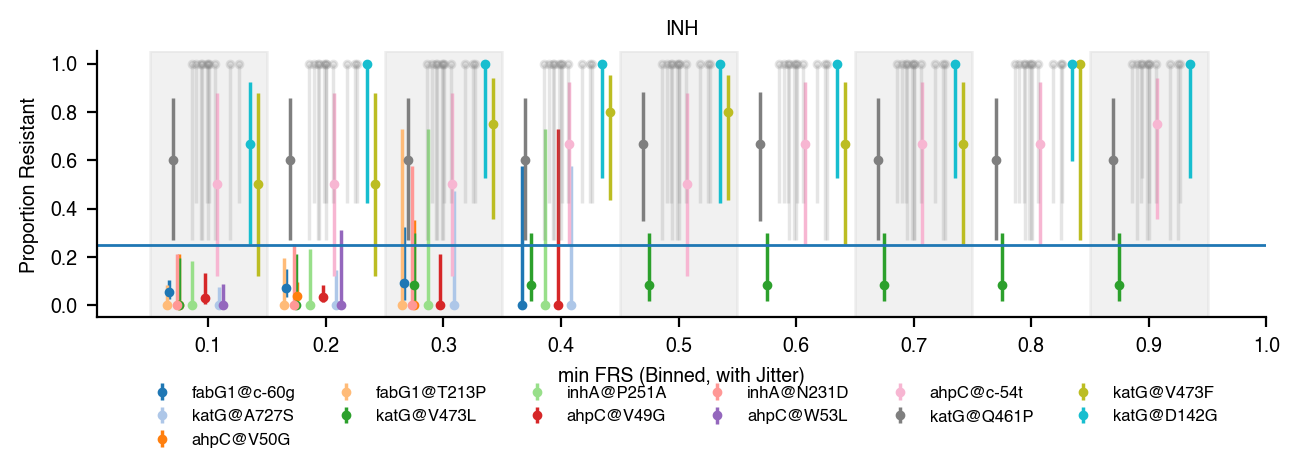

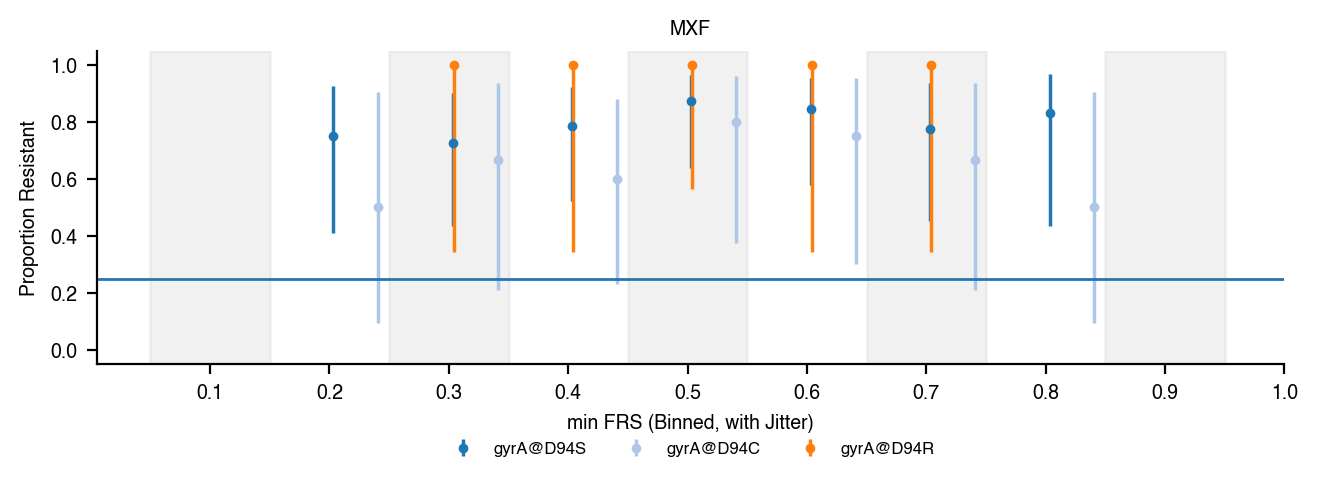

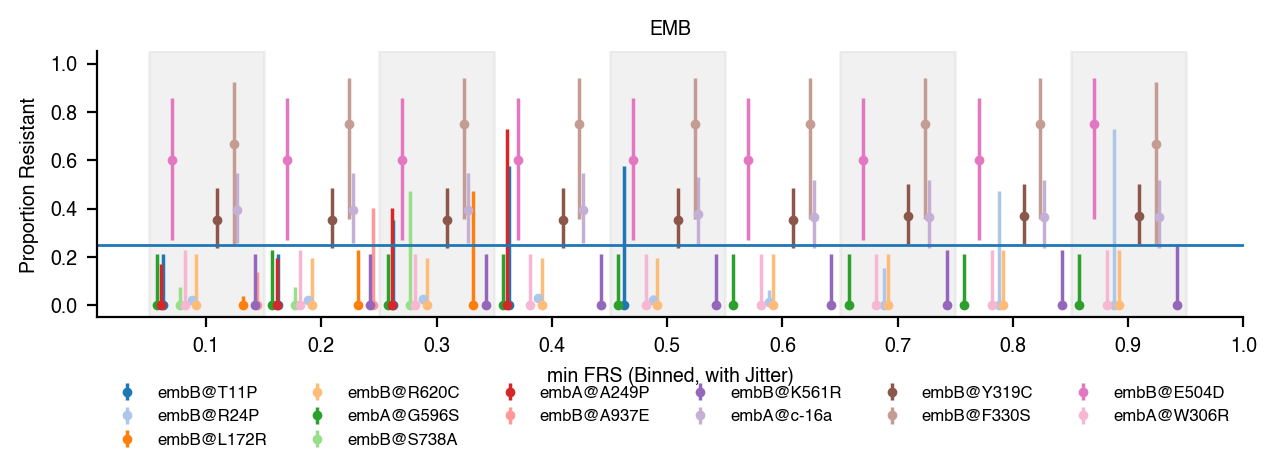

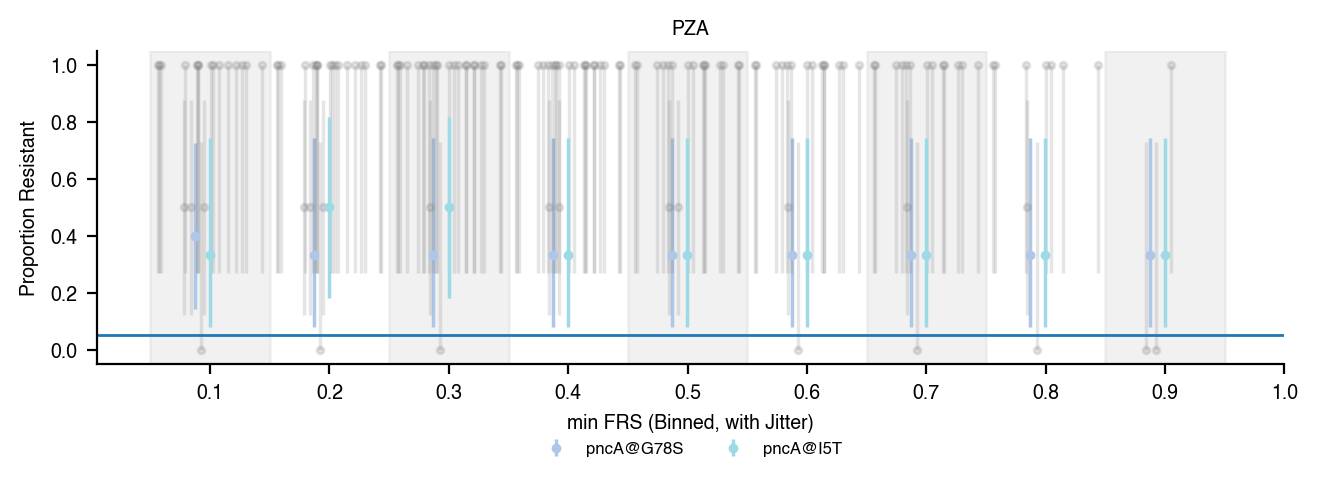

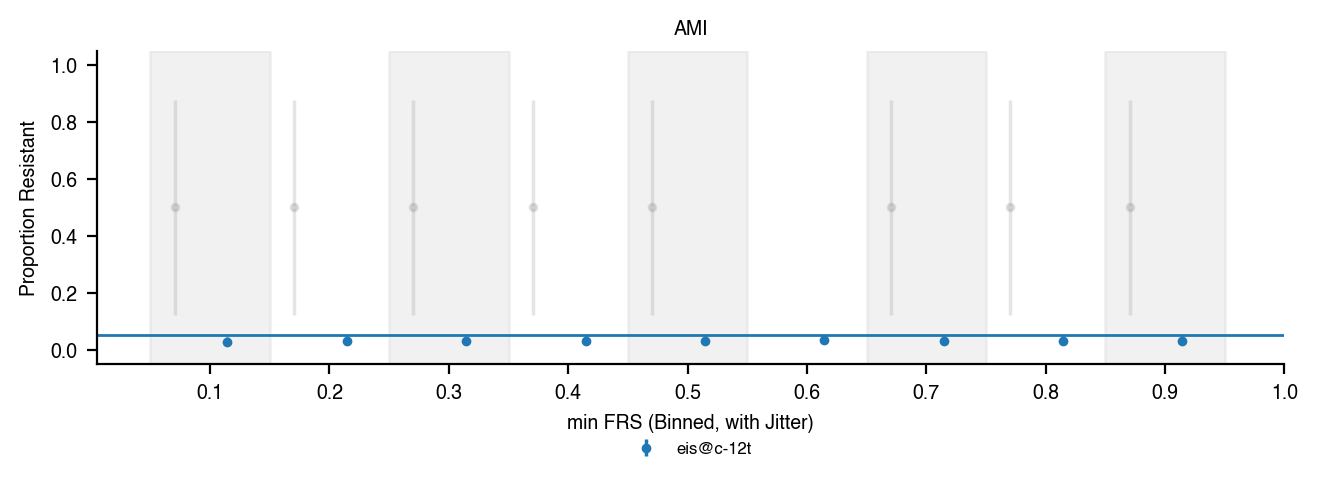

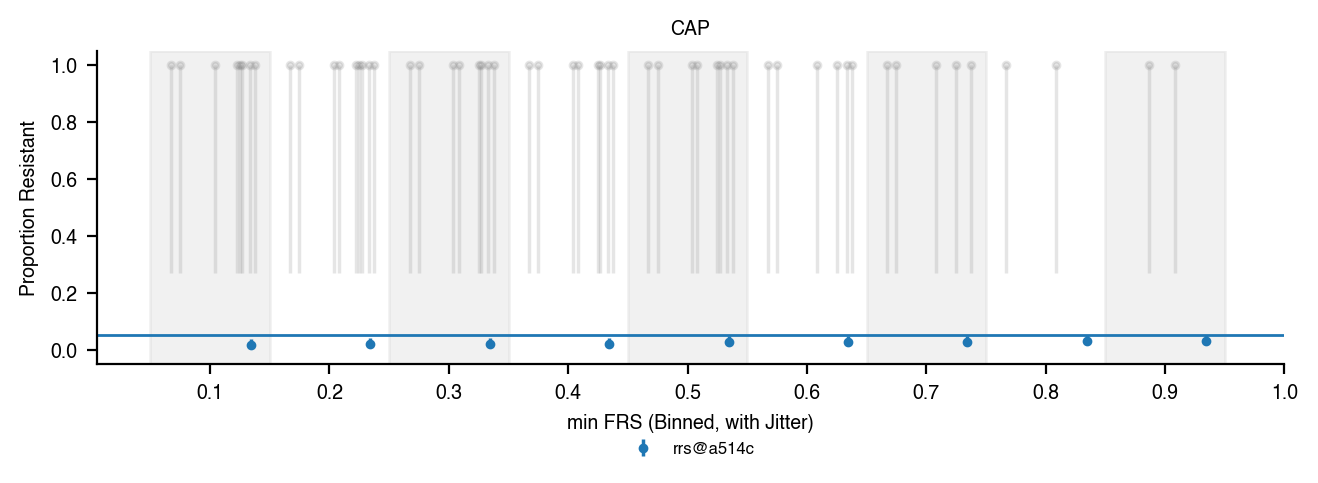

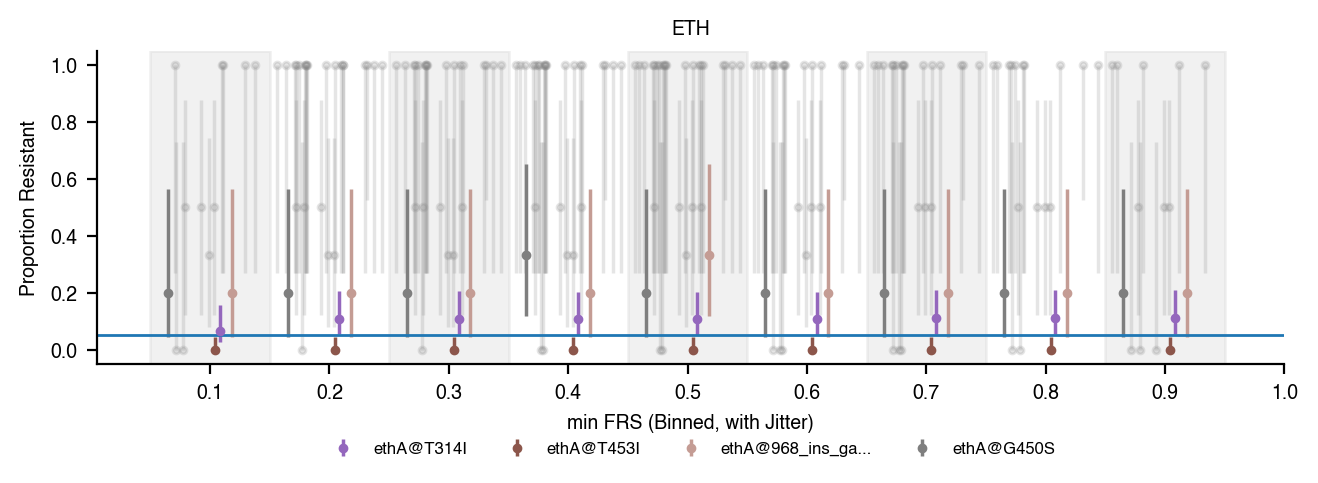

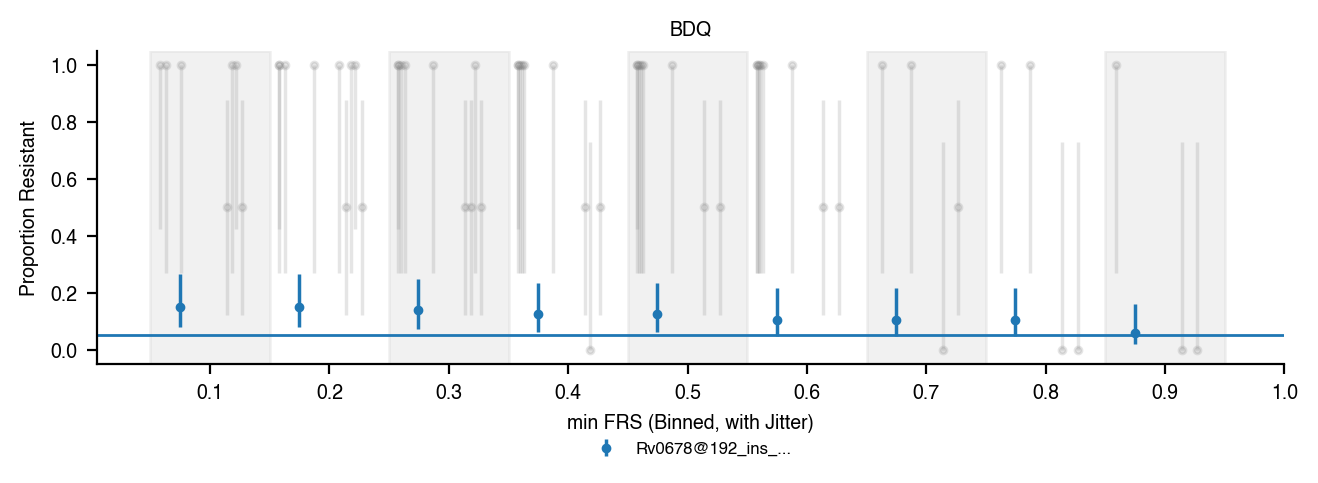

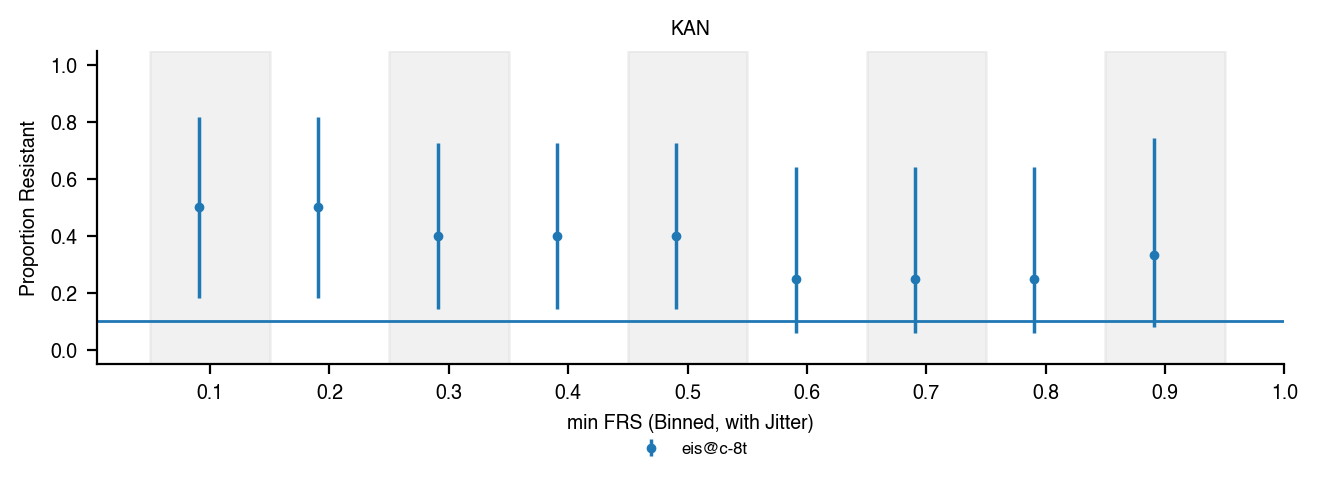

/Users/dylanadlard/Documents/Oxford/PhD/Projects/cryptic-catalogues-2025/protocols/graphs.py:696: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


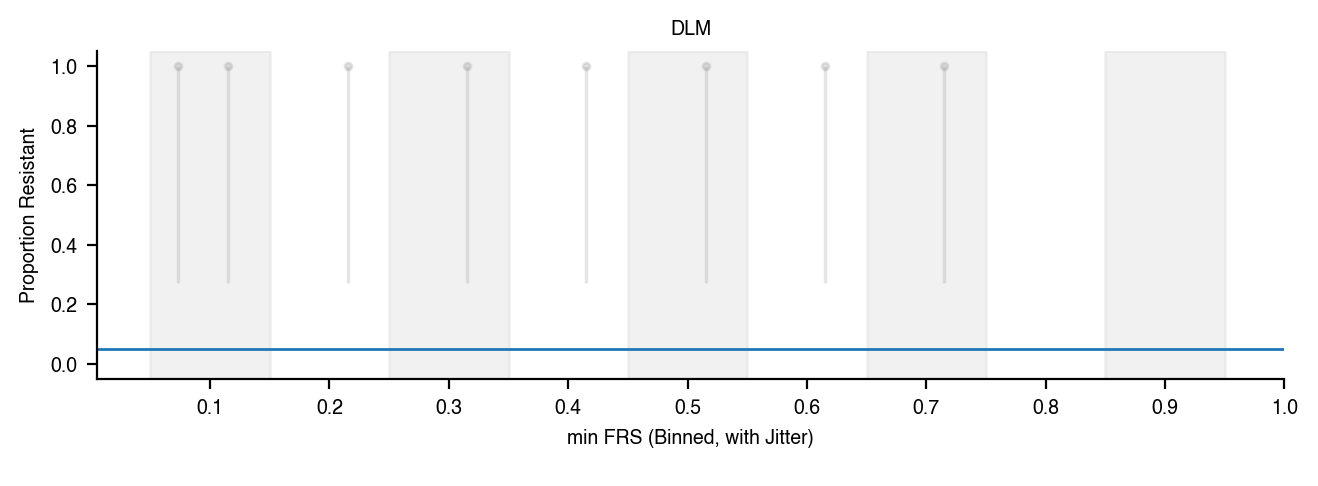

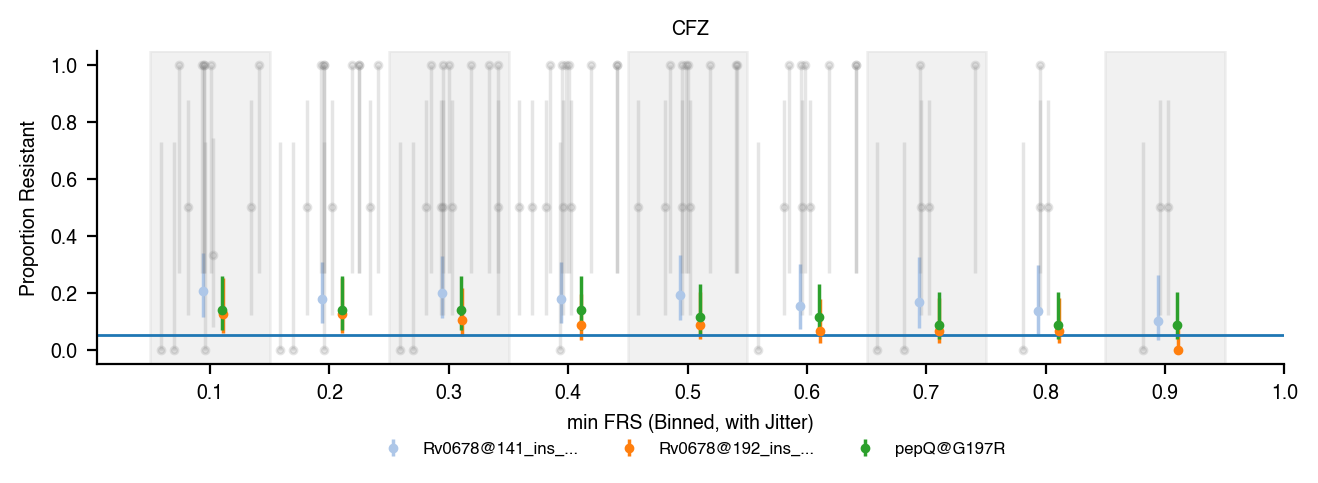

In [33]:
#plot error bars for mutations that change classification as minimum FRS is varied
color_map = {}
for drug, mutations_dict in frs_prop_data.items():
    unique_mutations = list(mutations_dict.keys())
    color_map[drug] = dict(zip(unique_mutations, sns.color_palette("tab20", len(unique_mutations))))

graphs.plot_mutation_error_bars(frs_prop_data, color_map=color_map, min_err=1, figpath='figs/frs/')

# Investigate the burden of minor alleles 

### Plot FRS distributions below FRS 0.9

Stratify by essential/non-essential violin plots

In [34]:
#read in phylogenetic mutations (doi:  10.1186/s13073-020-00726-5)
phylogenetics = pd.read_csv('data/13073_2020_726_MOESM3_ESM (4).csv')
phylogenetics['MUTATION'] = phylogenetics['GeneName'] + '@' + phylogenetics['group_subst'].str.split(' ').str[0]
phylogenetics

,# group_id,ref,pos,gene,GeneName,annotation,category,PureSNP,group_allel,number_group_strains,...,pheno-S that are geno-R,pheno-S minus geno-R,pheno-R,pheno-R that are geno-R,pheno-R minus geno-R,true S + unexplained R,(true S)/(true S+unexplained R),ratio >0.9 = neutral,comment,MUTATION
0,group_311,G,5072,-,gyrB_upstream,-,-,1.0,T,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,no data,NaN,NaN,gyrB_upstream@5072
1,group_290,C,5075,-,gyrB_upstream,-,-,1.0,T,11.0,...,NaN,NaN,NaN,NaN,NaN,NaN,no data,NaN,NaN,gyrB_upstream@5075
2,group_329,A,5082,-,gyrB_upstream,-,-,0.0,GAP,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,no data,NaN,NaN,gyrB_upstream@5082_GAP
3,group_330,C,5671,Rv0005,gyrB,DNA gyrase (subunit B) GyrB (DNA topoisomerase...,essential,1.0,T,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,no data,NaN,NaN,gyrB@Y144Y
4,group_327,G,5752,Rv0005,gyrB,DNA gyrase (subunit B) GyrB (DNA topoisomerase...,essential,1.0,A,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,no data,NaN,NaN,gyrB@V171V
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
543,unique strain,C,737857,Rv0643c,mmaA3,Methoxy mycolic acid synthase 3 MmaA3 (methyl ...,essential,1.0,A,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,no data,NaN,NaN,mmaA3@G98D
544,group_302,wt,NaN,Rv1979c,Rv1979c,Possible conserved permease,nonessential,0.0,deleted,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,no data,NaN,convergent evolution by (partial) deletion of ...,Rv1979c@uncovered
545,unique strain,wt,NaN,Rv1979c,Rv1979c,Possible conserved permease,nonessential,0.0,deleted,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,no data,NaN,convergent evolution by (partial) deletion of ...,Rv1979c@partially
546,unique strain,wt,NaN,Rv1979c,Rv1979c,Possible conserved permease,nonessential,0.0,deleted,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,no data,NaN,convergent evolution by (partial) deletion of ...,Rv1979c@uncovered


In [35]:
#define essential and non-essnetial genes (doi: 10.1186/s13073-020-00726-5)
essential = {'essential':["rpoB", "gyrA", "gyrB", "rplC",  "atpE",  "rpsL", 'rrs', "embA", "embB",], 'non_essential':["eis", "tlyA", "pepQ", "inhA", "ethA", "ahpC", "katG", "ddn", "pncA", "Rv0678", "gid", "fabG1"]}
#import mutations and prep catalogues for each gene to recreate training set
for type, genes in essential.items():
    mutations = functions.prep_mutations('data/mutations-v3.4.0/', 
                                        genes, 
                                        version='v3.4.0', 
                                        mut_path=cryptic_tables_path+'MUTATIONS.parquet', 
                                        var_path=cryptic_tables_path+'VARIANTS.parquet', 
                                        train=True)
    catalogue = pd.read_csv('catalogues/MTBC-CRyPTICv1.1.1-2025.8.csv')
    #mutations = mutations[mutations.MUTATION.isin(catalogue[catalogue.PREDICTION=='R'].MUTATION.values)]
    mutations = mutations[~mutations.MUTATION.isin(phylogenetics.MUTATION.values)]
    mutations['GENE'] = [i.split('@')[0] for i in mutations.MUTATION]
    if type=='essential':
        essential_frs = mutations.FRS.tolist()
        essential_gene_list = mutations.GENE.tolist()
    elif type=='non_essential':
        non_essential_frs = mutations.FRS.tolist()
        non_essential_gene_list = mutations.GENE.tolist()
    


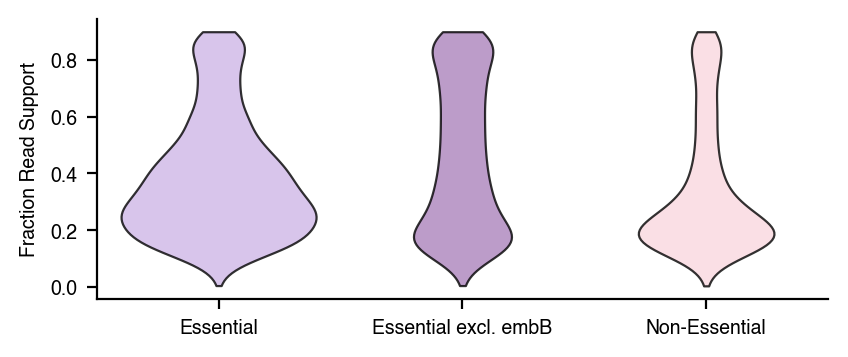

In [36]:
# Create base dataframe
data = pd.DataFrame({
    "Read Support": essential_frs + non_essential_frs,
    "Gene Category": ["Essential"] * len(essential_frs) + ["Non-Essential"] * len(non_essential_frs),
    "Gene": essential_gene_list + non_essential_gene_list
})

graphs.split_FRS_essential_violins(data)

In [37]:
# Define threshold for minor alleles
threshold = 0.9

# Count mutations below threshold
minor_essential = np.sum(np.array(essential_frs) <= threshold)
minor_nonessential = np.sum(np.array(non_essential_frs) <= threshold)

# Total number of mutations in each group
total_essential = len(essential_frs)
total_nonessential = len(non_essential_frs)

# Run the two-proportion z-test
count = [minor_essential, minor_nonessential]
nobs = [total_essential, total_nonessential]

stat, pval = proportions_ztest(count, nobs, alternative='larger')

print(f"Essential minor alleles: {minor_essential} / {total_essential}")
print(f"Non-essential minor alleles: {minor_nonessential} / {total_nonessential}")
print(f"Z-statistic: {stat:.3f}")
print(f"P-value: {pval}")

Essential minor alleles: 12906 / 100676
Non-essential minor alleles: 10021 / 112460
Z-statistic: 29.075
P-value: 3.6833636150809775e-186


## Plot frs vs gene violin plots

Stratify the above plot by gene:

To constrict to R alleles only, just comment back in the filter below

['rpoB', 'gyrA', 'gyrB', 'rplC', 'atpE', 'rpsL', 'rrs', 'embA', 'embB']
['eis', 'tlyA', 'pepQ', 'inhA', 'ethA', 'ahpC', 'katG', 'ddn', 'pncA', 'Rv0678', 'gid', 'fabG1']


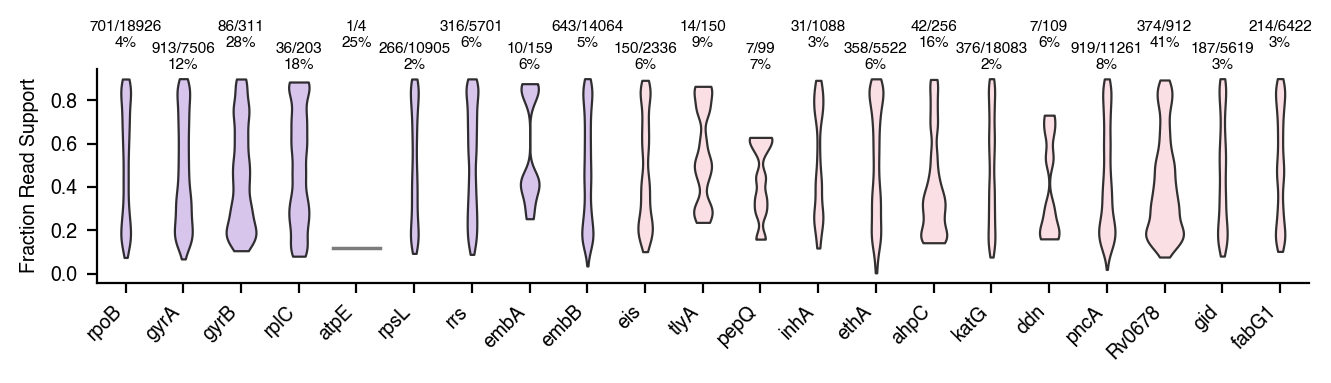

In [38]:
essential = {'essential':["rpoB", "gyrA", "gyrB", "rplC", "atpE",  "rpsL", 'rrs', "embA", "embB",], 'non_essential':["eis", "tlyA", "pepQ", "inhA", "ethA", "ahpC", "katG", "ddn", "pncA", "Rv0678", "gid", "fabG1"]}

combined_data = []

for cat, genes in essential.items():
    mutations = functions.prep_mutations(
        'data/mutations-v3.4.0/',
        genes,
        version='v3.4.0',
        mut_path=cryptic_tables_path + 'MUTATIONS.parquet',
        var_path=cryptic_tables_path + 'VARIANTS.parquet',
        train=True
    )
    catalogue = pd.read_csv('catalogues/MTBC-CRyPTICv1.1.1-2025.8.csv')
    mutations = mutations[mutations.MUTATION.isin(catalogue[catalogue.PREDICTION=='R'].MUTATION.values)]
    mutations = mutations[~mutations.MUTATION.isin(phylogenetics.MUTATION.values)]

    print (genes)

    mutations['GENE'] = mutations['MUTATION'].str.split('@').str[0]
    mutations = mutations[mutations.GENE.isin(genes)]
    mutations['Category'] = "Essential" if cat == 'essential' else "Non-Essential"
    combined_data.append(mutations[['GENE', 'FRS', 'Category']])

all_mutations = pd.concat(combined_data)

graphs.frs_gene_violins(all_mutations)

In [39]:
genes

['eis',
 'tlyA',
 'pepQ',
 'inhA',
 'ethA',
 'ahpC',
 'katG',
 'ddn',
 'pncA',
 'Rv0678',
 'gid',
 'fabG1']